# Financial AI Multi-Agent System with Vinagent

_Contributor: Gia Bao; Reviewed & Extended by: Kan Pham_

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/datascienceworld-kan/vinagent/blob/main/cookbook/multi_agent_in_finance/01_sequential_financial_analyst_crew.ipynb)


## Overview

In this tutorial, we will build a **Financial AI Multi-Agent System** using the Vinagent library. The system consists of four specialized agents working together in a pipeline:

```
User Query → Searcher Agent → Hypothesis Agent → Signal Builder Agent → Reporter Agent → Output
```

| Agent | Role |
|---|---|
| **Searcher Agent** | Gathers financial data and market news using web search and stock data tools |
| **Hypothesis Agent** | Analyzes the collected data and formulates investment hypotheses |
| **Signal Builder Agent** | Converts hypotheses into actionable trading signals with confidence scores |
| **Reporter Agent** | Generates a comprehensive visualization report with charts and recommendations |

### Prerequisites

- Vinagent >= 0.0.6.post6
- API keys for OpenAI and Tavily (for web search)

## Install Dependencies

In [1]:
%pip install -U vinagent==0.0.6.post6
%pip install --no-cache-dir "numpy<2.0" matplotlib==3.7.1
%pip install python-dotenv==1.0.0 tavily-python==0.7.7 plotly==5.22.0 Vnstock==3.4.2 -q

  Using cached vinagent-0.0.6.post6-py3-none-any.whl (151 kB)
  Using cached aucodb-0.1.8.post3-py3-none-any.whl (34 kB)
  Attempting uninstall: aucodb
    Found existing installation: aucodb 0.1.7
    Uninstalling aucodb-0.1.7:
      Successfully uninstalled aucodb-0.1.7
  Attempting uninstall: vinagent
    Found existing installation: vinagent 0.0.6
    Uninstalling vinagent-0.0.6:
      Successfully uninstalled vinagent-0.0.6

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Configuration

First, let's set up our environment. You should define `OPENAI_API_KEY` and `TAVILY_API_KEY` in a `.env` file.

In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv('.env'))

llm = ChatOpenAI(
    model="gpt-4o-mini"
)

print("LLM initialized successfully!")

LLM initialized successfully!


In [3]:
from datetime import datetime
from vinagent.register import primary_function

@primary_function
def get_current_time() -> str:
    """
    Get the current date and time. Use this to know 'today's' date.
    Returns:
        str: Current date and time in YYYY-MM-DD HH:MM:SS format.
    """
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Custom time tool defined.")

Custom time tool defined.


## Understanding the Multi-Agent Architecture

Vinagent's multi-agent system is built on three key concepts:

1. **`AgentNode`**: A proxy class that combines Vinagent's `Agent` (with LLM, tools, memory) and a graph `Node`. Each agent must implement the `exec(state)` method.

2. **`FlowStateGraph`**: Defines how agents are connected and the order of execution using the `>>` operator.

3. **`CrewAgent`**: Orchestrates the multi-agent system, compiling the graph and managing shared state.

The shared `State` dictionary allows agents to pass data to each other through the pipeline.

## Define the Shared State

The state is a `TypedDict` that all agents share. It holds the conversation messages and intermediate results from each agent. The `Annotated` type with a reducer function tells the graph how to merge updates.

In [4]:
from typing import Annotated, TypedDict

# Reducer: appends new messages to the existing list
def append_messages(existing: list, update: str) -> list:
    return existing + [update]

class FinancialState(TypedDict):
    """Shared state across all financial agents."""
    messages: Annotated[list[str], append_messages]  # Conversation history
    search_results: str     # Raw search data from Searcher
    hypothesis: str         # Investment hypothesis from Hypothesis Agent
    signals: str            # Trading signals from Signal Builder
    report: str             # Final report from Reporter

print("FinancialState schema defined.")

FinancialState schema defined.


## Define Agent Classes

Each agent extends `AgentNode` and implements an `exec(state)` method. This method:
- Reads from the shared state
- Calls `self.invoke(...)` to interact with its LLM
- Returns a dict that updates the shared state

### Searcher Agent

The Searcher gathers raw data about a stock using web search and stock data tools.

In [5]:
from vinagent.multi_agent import AgentNode, CrewAgent
from vinagent.logger.logger import logging_message

class Searcher(AgentNode):
    """Gathers financial data and news about a stock."""
    @logging_message
    def exec(self, state: FinancialState) -> dict:
        # Get the user query from the latest message
        query = state["messages"][-1]["content"]
        # Use the agent's LLM + tools to search for data
        output = self.invoke(query)
        result_text = output.content if hasattr(output, 'content') else str(output)
        return {
            "messages": {"role": "Searcher", "content": output},
            "search_results": result_text
        }

print("Searcher agent class defined.")


Searcher agent class defined.


### Hypothesis Agent

The Hypothesis Agent analyzes the search results and formulates investment hypotheses.

In [6]:
class HypothesisAgent(AgentNode):
    """Formulates investment hypotheses based on collected data."""
    @logging_message
    def exec(self, state: FinancialState) -> dict:
        # Build context from search results
        search_data = state.get("search_results", "No data available")
        prompt = (
            f"Based on the following financial data and news, "
            f"formulate clear investment hypotheses:\n\n"
            f"{search_data}"
        )
        output = self.invoke(prompt)
        result_text = output.content if hasattr(output, 'content') else str(output)
        return {
            "messages": {"role": "HypothesisAgent", "content": output},
            "hypothesis": result_text
        }

print("HypothesisAgent class defined.")


HypothesisAgent class defined.


### Signal Builder Agent

The Signal Builder converts hypotheses into actionable trading signals with buy/sell/hold recommendations.

In [7]:
class SignalBuilder(AgentNode):
    """Converts hypotheses into actionable trading signals."""
    @logging_message
    def exec(self, state: FinancialState) -> dict:
        hypothesis = state.get("hypothesis", "No hypothesis available")
        search_data = state.get("search_results", "No data available")
        prompt = (
            f"Based on the following investment hypotheses and market data, "
            f"generate clear trading signals.\n\n"
            f"Hypotheses:\n{hypothesis}\n\n"
            f"Market Data:\n{search_data}"
        )
        output = self.invoke(prompt)
        result_text = output.content if hasattr(output, 'content') else str(output)
        return {
            "messages": {"role": "SignalBuilder", "content": output},
            "signals": result_text
        }

print("SignalBuilder agent class defined.")


SignalBuilder agent class defined.


### Reporter Agent

The Reporter produces the final comprehensive report with visualizations and investment recommendations.

In [8]:
class Reporter(AgentNode):
    """Generates comprehensive financial report with visualizations."""
    @logging_message
    def exec(self, state: FinancialState) -> dict:
        search_data = state.get("search_results", "")
        hypothesis = state.get("hypothesis", "")
        signals = state.get("signals", "")
        prompt = (
            f"Create a comprehensive financial analysis report based on ALL the "
            f"following information. The report should use markdown format.\n\n"
            f"=== MARKET DATA ===\n{search_data}\n\n"
            f"=== INVESTMENT HYPOTHESES ===\n{hypothesis}\n\n"
            f"=== TRADING SIGNALS ===\n{signals}"
        )
        output = self.invoke(prompt)
        result_text = output.content if hasattr(output, 'content') else str(output)
        return {
            "messages": {"role": "Reporter", "content": output},
            "report": result_text
        }

print("Reporter agent class defined.")


Reporter agent class defined.


## Instantiate the Agents

Now we create agent instances with their specific configurations: name, description, instruction, LLM, skills, and tools.

Each agent gets its own identity and specialized behavior through these parameters.

> **Note**: The `tools` parameter accepts module paths (e.g., `'vinagent.tools.websearch_tools'`). Vinagent auto-discovers and registers all `@primary_function` decorated functions from these modules.

In [9]:
import os
import datetime
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from typing import Union, Any
from dotenv import load_dotenv
from tavily import TavilyClient
from dataclasses import dataclass
from plotly.subplots import make_subplots
from vnstock import Vnstock
from vinagent.register import primary_function

_ = load_dotenv()


def fetch_stock_data_vn(
    symbol: str,
    start_date: str = "2020-01-01",
    end_date: str = "2025-01-01",
    interval: str = "1d",
) -> pd.DataFrame:
    """
    Fetch historical stock data from Vnstock.

    Args:
        symbol (str): The stock symbol (e.g., 'FPT' for FPT Corporation).
        start_date (str): Start date for historical data (YYYY-MM-DD).
        end_date (str): End date for historical data (YYYY-MM-DD).
        interval (str): Data interval ('1d', '1wk', '1mo', etc.).

    Returns:
        pd.DataFrame: DataFrame containing historical stock prices.
    """
    try:
        stock = Vnstock().stock(symbol=symbol, source="VCI")
        df = stock.quote.history(start=start_date, end=end_date, interval=interval)
        return df
    except Exception as e:
        error_msg = f"Error fetching data for {symbol}: {e}"
        print(error_msg)
        return error_msg


def visualize_stock_data_vn(
    symbol: str,
    start_date: str = "2020-01-01",
    end_date: str = "2025-01-01",
    interval: str = "1d",
) -> None:
    """
    Visualize stock data with multiple chart types.

    Args:
        symbol (str): Stock symbol (e.g., 'AAPL')
        start_date (str): Start date (YYYY-MM-DD)
        end_date (str): End date (YYYY-MM-DD). It must be greater than start_date.
        interval (str): Data interval ('1d', '1wk', '1mo')
    """
    df = fetch_stock_data_vn(symbol, start_date, end_date, interval)
    if df is None or isinstance(df, str):
        return

    df = df.reset_index()

    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(df["time"], df["close"], label="Close Price", color="blue")
    plt.title(f"{symbol} Stock Price and Volume")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.bar(df["time"], df["volume"], color="gray")
    plt.ylabel("Volume")
    plt.xlabel("Date")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        subplot_titles=("Candlestick", "Volume"),
        row_heights=[0.7, 0.3],
    )

    fig.add_trace(
        go.Candlestick(
            x=df["time"],
            open=df["open"],
            high=df["high"],
            low=df["low"],
            close=df["close"],
            name="OHLC",
        ),
        row=1,
        col=1,
    )

    df["MA20"] = df["close"].rolling(window=20).mean()
    fig.add_trace(
        go.Scatter(
            x=df["time"],
            y=df["MA20"],
            line=dict(color="purple", width=1),
            name="20-day MA",
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Bar(x=df["time"], y=df["volume"], name="Volume", marker_color="gray"),
        row=2,
        col=1,
    )

    fig.update_layout(
        title=f"{symbol} Stock Price Analysis",
        yaxis_title="Price ($)",
        height=800,
        showlegend=True,
        template="plotly_white",
    )

    fig.update_xaxes(rangeslider_visible=False)
    fig.update_yaxes(title_text="Volume", row=2, col=1)

    fig.show()
    return fig


def plot_returns_vn(
    symbol: str,
    start_date: str = "2020-01-01",
    end_date: str = "2025-01-01",
    interval: str = "1d",
) -> None:
    """
    Visualize cumulative returns of the stock.
    """
    df = fetch_stock_data_vn(symbol, start_date, end_date, interval)
    if df is None or isinstance(df, str):
        return

    df["Daily_Return"] = df["close"].pct_change()
    df["Cumulative_Return"] = (1 + df["Daily_Return"]).cumprod() - 1

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df["Cumulative_Return"] * 100,
            mode="lines",
            name="Cumulative Return",
            line=dict(color="green"),
        )
    )

    fig.update_layout(
        title=f"{symbol} Cumulative Returns",
        xaxis_title="Date",
        yaxis_title="Return (%)",
        template="plotly_white",
        height=500,
    )

    fig.show()
    return fig


class WebSearchClient:
    tavily_client = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))

    def call_api(self, query: Union[str, dict[str, str]]):
        if isinstance(query, dict):
            query_string = "\n".join([f"{k}: {v}" for (k, v) in query.items()])
        else:
            query_string = query
        result = self.tavily_client.search(query_string, include_answer=True)
        return result["answer"]


def search_api(query: Union[str, dict[str, str]]) -> Any:
    """
    Search for an answer from a query string
    Args:
        query (dict[str, str]):  The input query to search
    Returns:
        The answer from search query
    """
    client = WebSearchClient()
    answer = client.call_api(query)
    return answer


def get_current_time() -> str:
    """Get the current date and time."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def fetch_btc_market_data() -> str:
    """
    Fetch comprehensive Bitcoin (BTC) market data including price, changes (daily/weekly/monthly), and moving averages from the CoinDesk API.
    Returns:
        str: A comprehensive summary of BTC market metrics.
    """
    try:
        response = requests.get(
            "https://data-api.coindesk.com/index/cc/v1/latest/tick",
            params={
                "market": "cadli",
                "instruments": "BTC-USD",
                "apply_mapping": "true",
            },
            headers={"Content-type": "application/json; charset=UTF-8"},
        )
        data = response.json()["Data"]["BTC-USD"]

        summary = (
            f"--- BTC-USD Market Data ---\n"
            f"Current Price: ${data['VALUE']:.2f} USD\n"
            f"Day Change: {data['CURRENT_DAY_CHANGE']:.2f} ({data['CURRENT_DAY_CHANGE_PERCENTAGE']:.2f}%)\n"
            f"Week Change: {data['CURRENT_WEEK_CHANGE']:.2f} ({data['CURRENT_WEEK_CHANGE_PERCENTAGE']:.2f}%)\n"
            f"Month Change: {data['CURRENT_MONTH_CHANGE']:.2f} ({data['CURRENT_MONTH_CHANGE_PERCENTAGE']:.2f}%)\n"
            f"24h Range: ${data['MOVING_24_HOUR_LOW']:.2f} - ${data['MOVING_24_HOUR_HIGH']:.2f}\n"
            f"Year Change: {data['CURRENT_YEAR_CHANGE_PERCENTAGE']:.2f}%\n"
            f"Volatility Context: Day High ${data['CURRENT_DAY_HIGH']:.2f} / Low ${data['CURRENT_DAY_LOW']:.2f}"
        )
        return summary
    except Exception as e:
        return f"Error fetching BTC price: {e}"


@primary_function
def calculate_black_litterman(
    symbols: list, priors: list, views: list, tau: float = 0.05
) -> dict:
    """
    Perform Black-Litterman calculation to get posterior returns.

    Args:
        symbols (list): A list of stock ticker symbols (e.g., ['FPT', 'CMG', 'VGI']).
        priors (list): A list of prior expected returns (floats) for each symbol.
        views (list): A list of subjective market views (dictionaries). Leave empty [] if none.
        tau (float): Scalar indicating the uncertainty of the prior.
    """
    try:
        import numpy as np

        n = len(symbols)
        sigma = np.eye(n) * 0.05
        pi = np.array(priors).reshape(-1, 1)
        k = len(views)
        if k == 0:
            return {symbols[i]: float(priors[i]) for i in range(n)}
        P, Q, Omega = np.zeros((k, n)), np.zeros((k, 1)), np.zeros((k, k))
        for i, v in enumerate(views):
            for s, w in zip(v["symbols"], v["weights"]):
                if s in symbols:
                    P[i, symbols.index(s)] = w
            Q[i, 0], Omega[i, i] = v["return"], (1.001 - v["confidence"]) * 0.1
        ts_inv, o_inv = np.linalg.inv(tau * sigma), np.linalg.inv(Omega)
        res = np.linalg.inv(ts_inv + P.T @ o_inv @ P) @ (ts_inv @ pi + P.T @ o_inv @ Q)
        return {symbols[i]: round(float(res[i, 0]), 4) for i in range(n)}
    except Exception as e:
        return {"error": str(e)}


@primary_function
def optimize_portfolio(
    symbols: list, expected_returns: dict, risk_aversion: float = 2.5
) -> dict:
    """
    Perform Mean-Variance Optimization to generate target weights.

    Args:
        symbols (list): A list of stock ticker symbols.
        expected_returns (dict): Dictionary mapping symbols to their expected returns.
        risk_aversion (float): The risk aversion coefficient.
    """
    try:
        import numpy as np

        n = len(symbols)
        sigma = np.eye(n) * 0.05
        mu = np.array([expected_returns[s] for s in symbols]).reshape(-1, 1)
        w = np.linalg.inv(risk_aversion * sigma) @ mu
        wn = np.maximum(w, 0)
        if wn.sum() > 0:
            wn = wn / wn.sum()
        return {symbols[i]: round(float(wn[i, 0]), 4) for i in range(n)}
    except Exception as e:
        return {"error": str(e)}


@primary_function
def calculate_equilibrium_returns(
    symbols: list, risk_free_rate: float = 0.03, market_risk_premium: float = 0.05
) -> dict:
    """
    Calculate CAPM-based equilibrium returns (priors) for Black-Litterman.

    Args:
        symbols (list): A list of stock ticker symbols (e.g., ['FPT', 'CMG', 'VGI']).
        risk_free_rate (float): The risk-free rate.
        market_risk_premium (float): The expected market premium.
    """
    try:
        results = {}
        for s in symbols:
            betas = {"FPT": 1.1, "CMG": 1.3, "VGI": 1.2, "ELC": 1.4, "ITD": 1.1}
            beta = betas.get(s, 1.0)
            expected_return = risk_free_rate + beta * market_risk_premium
            results[s] = round(expected_return, 4)
        return results
    except Exception as e:
        return {"error": str(e)}


@primary_function
def backtest_alpha_strategy(
    symbol: str,
    strategy_type: str,
    start_date: str = "2020-01-01",
    end_date: str = "2025-01-01",
    **kwargs,
) -> dict:
    """
    Backtest a specific alpha strategy.
    Supported strategy_type: 'momentum', 'mean_reversion'.
    """
    try:
        import numpy as np

        df = fetch_stock_data_vn(symbol, start_date, end_date)
        if (
            df is None
            or (isinstance(df, pd.DataFrame) and df.empty)
            or isinstance(df, str)
        ):
            return {"error": f"No data found for {symbol}"}

        df["returns"] = df["close"].pct_change()

        if strategy_type == "momentum":
            window = kwargs.get("window", 20)
            df["signal"] = np.where(df["close"] > df["close"].shift(window), 1, -1)
        elif strategy_type == "mean_reversion":
            window = kwargs.get("window", 20)
            ma = df["close"].rolling(window).mean()
            std = df["close"].rolling(window).std()
            df["signal"] = np.where(
                df["close"] < ma - std,
                1,
                np.where(df["close"] > ma + std, -1, 0),
            )
        else:
            return {"error": f"Unsupported strategy type: {strategy_type}"}

        df["strategy_returns"] = df["signal"].shift(1) * df["returns"]
        df = df.dropna()

        cum_returns = (1 + df["strategy_returns"]).cumprod()
        sharpe = (
            (df["strategy_returns"].mean() / df["strategy_returns"].std())
            * np.sqrt(252)
            if df["strategy_returns"].std() != 0
            else 0
        )

        return {
            "strategy": strategy_type,
            "total_return": round(cum_returns.iloc[-1] - 1, 4),
            "annualized_return": (
                round((cum_returns.iloc[-1] ** (252 / len(df))) - 1, 4)
                if len(df) > 0
                else 0
            ),
            "sharpe_ratio": round(sharpe, 2),
            "max_drawdown": round(((cum_returns / cum_returns.cummax()) - 1).min(), 4),
        }
    except Exception as e:
        return {"error": str(e)}

Let's initialize specialized agents and register aforementioned tools into each one.

In [10]:
import os

# --- 1. Searcher Agent ---
searcher = Searcher(
    name="searcher",
    description="A financial research agent that gathers market data, stock prices, and financial news.",
    instruction=(
        "You are a financial research analyst. Use the get_current_time tool to find out 'today's' date, then gather comprehensive data about the given stock or financial topic. "
        " "
        "If fetch_stock_data_vn returns no data, DO NOT retry it indefinitely; instead, try a search_api query to confirm the correct symbol or verify current news. "
        "Use the search tool to find the latest news, analyst opinions, and market sentiment. "
        "Use stock data tools to fetch historical price data."
        "Use the get_current_time tool to find out 'today's' date. When fetching stock data, "
        "always set end_date to today's date and start_date to a reasonable past date "
        "(e.g., 5 years before today) to ensure the data is up-to-date and covers a sufficient period."

    ),
    llm=llm,
    skills=[
        "Search for financial news and market data",
        "Fetch and analyze stock price data",
        "Summarize market sentiment"
    ],
    tools=[
        'vinagent.tools.websearch_tools',
    ],
)

# --- 2. Hypothesis Agent ---
hypothesis_agent = HypothesisAgent(
    name="hypothesis_agent",
    description="An analyst agent that formulates investment hypotheses from research data.",
    instruction=(
        "You are a financial research analyst. Use the get_current_time tool to find out 'today's' date, then gather comprehensive data about the given stock or financial topic. "
        " "
        "If fetch_stock_data_vn returns no data, DO NOT retry it indefinitely; instead, try a search_api query to confirm the correct symbol or verify current news. "
        "Use the search tool to find the latest news, analyst opinions, and market sentiment. "
        "Use stock data tools to fetch historical price data."

    ),
    llm=llm,
    skills=[
        "Formulate data-driven investment hypotheses",
        "Identify bull and bear scenarios",
        "Assess risk factors"
    ]
)

# --- 3. Signal Builder Agent ---
signal_builder = SignalBuilder(
    name="signal_builder",
    description="A quantitative agent that converts hypotheses into actionable trading signals.",
    instruction=(
        "You are a financial research analyst. Use the get_current_time tool to find out 'today's' date, then gather comprehensive data about the given stock or financial topic. "
        " "
        "If fetch_stock_data_vn returns no data, DO NOT retry it indefinitely; instead, try a search_api query to confirm the correct symbol or verify current news. "
        "Use the search tool to find the latest news, analyst opinions, and market sentiment. "
        "Use stock data tools to fetch historical price data."

    ),
    llm=llm,
    skills=[
        "Generate BUY/SELL/HOLD signals",
        "Calculate risk/reward ratios",
        "Set target prices and stop-losses"
    ]
)

# --- 4. Reporter Agent ---
reporter = Reporter(
    name="reporter",
    description="A reporting agent that creates comprehensive financial analysis reports with visualizations.",
    instruction=(
        "You are a financial research analyst. Use the get_current_time tool to find out 'today's' date, then gather comprehensive data about the given stock or financial topic. "
        " "
        "If fetch_stock_data_vn returns no data, DO NOT retry it indefinitely; instead, try a search_api query to confirm the correct symbol or verify current news. "
        "Use the search tool to find the latest news, analyst opinions, and market sentiment. "
        "Use stock data tools to fetch historical price data."

    ),
    llm=llm,
    skills=[
        "Write professional financial reports",
        "Create data visualizations",
        "Summarize complex analysis clearly"
    ]
)

print("All 4 agents instantiated successfully!")
# Register the custom tool manually for all agents
for agent in [searcher, hypothesis_agent, signal_builder, reporter]:
    agent.tools_manager.register_function_tool(get_current_time)
    agent.tools_manager.register_function_tool(fetch_stock_data_vn)
    agent.tools_manager.register_function_tool(visualize_stock_data_vn)
    agent.tools_manager.register_function_tool(plot_returns_vn)
print("Custom tool registered for all agents.")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:vinagent.register.tool:Registered search_api:
{'tool_name': 'search_api', 'arguments': 'query: Union[str, dict[str, str]]', 'return': 'The answer from search query', 'docstring': 'Search for an answer from a query string\n    Args:\n        query (dict[str, str]):  The input query to search\n    Returns:\n        The answer from search query', 'dependencies': ['os', 'dotenv', 'tavily', 'dataclasses', 'typing', 'vinagent'], 'module_path': 'vinagent.tools.websearch_tools', 'tool_type': 'module', 'tool_call_id': 'tool_74e1a595-f675-4e8e-9cbf-566ca9440fa'}
INFO:vinagent.register.tool:Completed registration for module vinagent.tools.websearch_tools
INFO:vinagent.register.tool:Registered tool: get_current_time (runtime)
INFO:vinagent.register.tool:Registered tool: fetch_stock_data_vn (runtime)
INFO:vinagent.register.tool:Registered tool: visualize_stock_data_vn (runtime)
INFO:vinagent.register.too

All 4 agents instantiated successfully!
Custom tool registered for all agents.


## Build the Multi-Agent Crew

Now we wire everything together using `CrewAgent` with a `FlowStateGraph`. The `>>` operator defines the execution flow:

```
searcher >> hypothesis_agent >> signal_builder >> reporter >> END
```

This creates a **linear pipeline** where each agent's output feeds into the next.

In [11]:
from vinagent.graph.operator import FlowStateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver

class ConfigSchema(TypedDict):
    user_id: str

# Build the crew with a linear flow
crew = CrewAgent(
    llm=llm,
    checkpoint=MemorySaver(),
    graph=FlowStateGraph(FinancialState, config_schema=ConfigSchema),
    flow=[
        searcher >> hypothesis_agent,
        hypothesis_agent >> signal_builder,
        signal_builder >> reporter,
        reporter >> END,
    ]
)

print("Financial multi-agent crew assembled!")

Financial multi-agent crew assembled!


### Visualize the Agent Graph

We can inspect the compiled graph to see the execution flow:

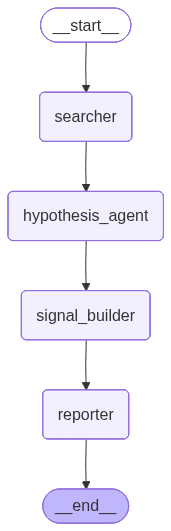

In [12]:
# Display the compiled graph
crew.compiled_graph

## Run the Financial Analysis

Let's invoke the multi-agent system with a financial query. The query will flow through all 4 agents:

1. **Searcher** gathers data about the stock
2. **Hypothesis Agent** formulates investment theses
3. **Signal Builder** generates trading signals
4. **Reporter** creates the final report

In [13]:
query = """Analyze FPT (FPT) stock. 
Research the current market situation, recent news, and provide investment recommendations."""

result = crew.invoke(
    query=query,
    user_id="analyst",
    thread_id=3
)

INFO:vinagent.multi_agent.crew:No authentication card provided, skipping authentication
INFO:vinagent.agent.agent:No authentication card provided, skipping authentication
INFO:vinagent.agent.agent:I'am chatting with unknown_user
INFO:vinagent.agent.agent:Tool calling iteration 1/10


{'input': {'messages': {'role': 'user', 'content': 'Analyze FPT (FPT) stock. \nResearch the current market situation, recent news, and provide investment recommendations.'}}, 'config': {'configurable': {'user_id': 'analyst'}, 'thread_id': 3}}


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:vinagent.agent.agent:Executing tool call: {'tool_name': 'get_current_time', 'arguments': {}, 'return': "<class 'str'>", 'module_path': '__runtime__', 'tool_type': 'function', 'tool_call_id': 'tool_32de6fb4-53ef-48bf-b1c4-8f2a11eda2c', 'is_runtime': True}
INFO:vinagent.register.tool:Completed executing function tool get_current_time({})
INFO:vinagent.agent.agent:Tool calling iteration 2/10
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:vinagent.agent.agent:Executing tool call: {'tool_name': 'fetch_stock_data_vn', 'arguments': {'symbol': 'FPT', 'start_date': '2021-03-04', 'end_date': '2026-03-04', 'interval': '1d'}, 'return': "<class 'pandas.core.frame.DataFrame'>", 'module_path': '__runtime__', 'tool_type': 'function', 'tool_call_id': 'tool_4d4b7fe9-8c10-48e4-836f-f5222345faf', 'is_runtime': True}
INFO:vinagent.register.tool:Completed executing

ERROR:vnai.scope.promo:Non-200 response fetching content: 400
ERROR:vnai.scope.promo:Non-200 response fetching content: 400


## View Agent-by-Agent Outputs

Let's examine what each agent contributed to the analysis:

In [14]:
# Print each agent's response
for msg in result['messages']:
    role = msg['role']
    content = msg['content'].content if hasattr(msg['content'], 'content') else msg['content']
    # Truncate long outputs for readability
    preview = content[:500] + '...' if len(content) > 500 else content
    print(f"{'='*60}")
    print(f"  {role}")
    print(f"{'='*60}")
    print(preview)
    print()

  user
Analyze FPT (FPT) stock. 
Research the current market situation, recent news, and provide investment recommendations.

  Searcher
FPT (FPT Corporation) stock has been fluctuating recently, with the latest closing price on March 3, 2026, at approximately 87,000 VND. Over the previous week, the stock ranged from 90,100 VND to 90,900 VND. The company is heavily investing in artificial intelligence (AI) and cybersecurity domains, which is reflective of their strategic initiatives to foster growth. 

As for investment recommendations, considering the recent performance and developments in the AI and cybersecurity sectors, poten...

  HypothesisAgent
Based on the provided financial data and news regarding FPT Corporation, the following investment hypotheses can be formulated:

1. **Growth Potential in AI and Cybersecurity**: FPT's significant investments in artificial intelligence and cybersecurity suggest a strong growth trajectory. This aligns with current market trends favoring tec

## Display the Final Report

The Reporter agent's output is a comprehensive markdown report. Let's render it:

In [15]:
from IPython.display import Markdown, display

# Render the final report as formatted markdown
report = result.get('report', 'No report generated.')
display(Markdown(report))

# FPT Corporation Financial Analysis Report

## Current Market Data
- **Stock Symbol:** FPT (FPT Corporation)
- **Latest Closing Price:** 87,000 VND (March 3, 2026)
- **Weekly Trading Range:** 90,100 VND - 90,900 VND
- **Sector Focus:** Heavy investment in artificial intelligence (AI) and cybersecurity

## Investment Hypotheses

1. **Growth Potential in AI and Cybersecurity**
   - FPT's significant investments in artificial intelligence and cybersecurity suggest a strong growth trajectory. This aligns with current market trends favoring technological advancements in these areas.

2. **Market Volatility Monitoring**
   - The recent fluctuation in FPT's stock price indicates potential volatility. Investors should remain cautious and monitor market conditions and sector-specific developments closely.

3. **Long-term Investment Opportunity**
   - FPT's strategic focus on high-growth sectors makes it an attractive option for long-term investors, despite short-term price fluctuations.

4. **Risk Assessment**
   - The interplay between market volatility and sector-specific investments introduces risk. Establishing a risk management strategy is recommended.

5. **Bull and Bear Scenarios**
   - **Bull Scenario:** Successful capitalizing on investments in AI and cybersecurity could lead to significant stock appreciation.
   - **Bear Scenario:** Deteriorating market conditions or setbacks could lead to declines below key support levels.

Overall, FPT Corporation is positioned as a potential growth stock, but careful monitoring of market conditions and risks is recommended.

## Trading Signals

1. **Signal:** **BUY**
   - **Reasoning:** Attractive long-term investment potential based on significant investments in AI and cybersecurity.

2. **Signal:** **HOLD**
   - **Reasoning:** Maintain position while monitoring market conditions amid recent volatility.

3. **Signal:** **SELL** if prices approach resistance levels.
   - **Risk Assessment:** If nearing resistance above 90,900 VND and underperformance is observed, a sell may be prudent.

4. **Target Price:**
   - Short-term target at 90,900 VND for potential profit taking.

5. **Stop-loss Level:**
   - Set stop-loss at 84,000 VND to minimize losses in case of significant price drops.

## Summary
Investors are encouraged to consider FPT as a growth-oriented opportunity, while monitoring market volatility and risks closely. The recommended strategies include a buy for long-term growth, holding amidst volatility, and implementing sell strategies if approaching resistance, complemented by sound risk management practices.

## Examining Individual Pipeline Outputs

We can also inspect the intermediate results from each agent:

In [16]:
# View Search Results
print("=" * 50)
print("SEARCH RESULTS")
print("=" * 50)
search_results = result.get('search_results', 'N/A')
print(search_results[:1000] if len(search_results) > 1000 else search_results)
print()

SEARCH RESULTS
FPT (FPT Corporation) stock has been fluctuating recently, with the latest closing price on March 3, 2026, at approximately 87,000 VND. Over the previous week, the stock ranged from 90,100 VND to 90,900 VND. The company is heavily investing in artificial intelligence (AI) and cybersecurity domains, which is reflective of their strategic initiatives to foster growth. 

As for investment recommendations, considering the recent performance and developments in the AI and cybersecurity sectors, potential investors may view FPT as a growth-oriented opportunity, albeit with the necessity to monitor market volatility and sector trends closely.



In [17]:
# View Hypotheses
print("=" * 50)
print("INVESTMENT HYPOTHESES")
print("=" * 50)
display(Markdown(result.get('hypothesis', 'N/A')))

INVESTMENT HYPOTHESES


Based on the provided financial data and news regarding FPT Corporation, the following investment hypotheses can be formulated:

1. **Growth Potential in AI and Cybersecurity**: FPT's significant investments in artificial intelligence and cybersecurity suggest a strong growth trajectory. This aligns with current market trends favoring technological advancements, specifically in these sectors. Investors may view FPT as a potential growth stock, particularly as these areas are expected to expand.

2. **Market Volatility Monitoring**: The recent fluctuation in FPT's stock price, with a closing price of approximately 87,000 VND and a weekly range between 90,100 VND and 90,900 VND, indicates potential volatility. Investors should remain cautious and continuously monitor market conditions and sector-specific developments which may impact stock performance.

3. **Long-term Investment Opportunity**: Given FPT's strategic focus on high-growth sectors, investors with a long-term perspective may find the stock attractive. Despite short-term price fluctuations, the fundamental developments in AI and cybersecurity could underpin the stock's value over time.

4. **Risk Assessment**: The interplay between market volatility and FPT's sector-specific investments introduces risk. Factors such as competition, regulatory changes, and technological advancements could individually impact performance. Investors could benefit from establishing a risk management strategy while investing in FPT.

5. **Bull and Bear Scenarios**:
   - **Bull Scenario**: If FPT successfully capitalizes on its investments in AI and cybersecurity, and overall market conditions remain favorable, the stock could experience significant appreciation, potentially exceeding initial resistance levels.
   - **Bear Scenario**: Conversely, if market conditions deteriorate, or FPT faces setbacks in its strategic initiatives, the stock could decline below key support levels identified in recent trading ranges.

Overall, FPT Corporation is positioned as a potential growth stock, although careful monitoring of market conditions and risks is recommended for investors.

In [18]:
# View Trading Signals
print("=" * 50)
print("TRADING SIGNALS")
print("=" * 50)
display(Markdown(result.get('signals', 'N/A')))

TRADING SIGNALS


Based on the investment hypotheses and market data for FPT Corporation, here are the trading signals:

1. **Signal:** **BUY**
   - **Reasoning:** Given the company's significant investments in AI and cybersecurity, it possesses strong growth potential, making it an attractive long-term investment.

2. **Signal:** **HOLD**
   - **Reasoning:** With the recent volatility, particularly with a close around 87,000 VND and a range between 90,100 VND and 90,900 VND, maintaining a position while monitoring the market conditions is advisable.

3. **Signal:** **SELL** if prices approach resistance levels.
   - **Risk Assessment:** If FPT's stock price approaches resistance above 90,900 VND and market conditions worsen or underperformance is observed, a sell may be prudent.

4. **Target Price:** 
   - Short-term target at 90,900 VND for potential profit taking.

5. **Stop-loss Level:**
   - Set stop-loss at 84,000 VND to minimize losses in case the stock price drops significantly below current levels.

In summary, investors are encouraged to buy for long-term growth, hold positions amid volatility, and consider a sell strategy if approaching resistance while also implementing a risk management strategy with target pricing and stop-loss orders.


## 👋 Chào mừng bạn đến với Vnstock!
Cảm ơn bạn đã sử dụng package phân tích chứng khoán #1 tại Việt Nam
* Tài liệu: [Sổ tay hướng dẫn](https://vnstocks.com/docs)
* Cộng đồng: [Nhóm Facebook](https://facebook.com/groups/vnstock.official)
Khám phá các tính năng mới nhất và tham gia cộng đồng để nhận hỗ trợ.
**📊 Phiên bản cộng đồng:** Báo cáo tài chính được giới hạn tối đa **4 kỳ** để minh hoạ thuật toán. Để truy cập đầy đủ, vui lòng [tham gia gói thành viên tài trợ dự án](https://vnstocks.com/insiders-program).
                


## 👋 Chào mừng bạn đến với Vnstock!
Cảm ơn bạn đã sử dụng package phân tích chứng khoán #1 tại Việt Nam
* Tài liệu: [Sổ tay hướng dẫn](https://vnstocks.com/docs)
* Cộng đồng: [Nhóm Facebook](https://facebook.com/groups/vnstock.official)
Khám phá các tính năng mới nhất và tham gia cộng đồng để nhận hỗ trợ.
**📊 Phiên bản cộng đồng:** Báo cáo tài chính được giới hạn tối đa **4 kỳ** để minh hoạ thuật toán. Để truy cập đầy đủ, vui lòng [tham gia gói thành viên tài trợ dự án](https://vnstocks.com/insiders-program).
                

## How It Works — Key Concepts

### Agent Definition Pattern

```python
class MyAgent(AgentNode): 
    @logging_message
    def exec(self, state: MyState) -> dict:
        # 1. Read from shared state
        data = state["some_field"]
        
        # 2. Call LLM (with tools if configured)
        output = self.invoke(data)
        
        # 3. Return updates to shared state
        return {
            "messages": {"role": "MyAgent", "content": output},
            "some_field": output.content
        }
```

### Flow Definition

```python
# Linear pipeline
flow = [
    agent_a >> agent_b,
    agent_b >> agent_c,
    agent_c >> END,
]

# Branching (with branching() method)
flow = [
    supervisor >> {
        "option_a": agent_a,
        "option_b": agent_b,
    },
    agent_a >> END,
    agent_b >> END,
]
```

### Key Takeaways

1. **Modularity**: Each agent is self-contained with its own LLM, tools, and instruction
2. **Shared State**: Agents communicate through a typed state dictionary
3. **Specialization**: Each agent focuses on one task (search, analyze, signal, report)
4. **Composability**: The `>>` operator makes it easy to rewire the pipeline
5. **Tool Integration**: Agents can use tools like web search and stock data APIs

## Next Steps

You can extend this system by:

- **Adding more tools**: Custom stock screeners, technical analysis indicators, financial statement parsers
- **Branching logic**: Use `branching()` to route different stock types to specialized agents
- **Memory**: Add persistent memory so the system remembers previous analyses
- **Human-in-the-loop**: Use `UserFeedback` nodes to let analysts approve/reject hypotheses before signal generation
- **Guardrails**: Add input/output guardrails to validate financial claims and prevent hallucinations